# Sarcasm Detection      (Total marks: 40)

### Load Data

In [1]:
import pandas as pd
import json
from google.colab import files

# Upload the JSON file
uploaded = files.upload()


Saving Sarcasm_Headlines_Dataset.json to Sarcasm_Headlines_Dataset.json


In [2]:
df = pd.read_json('Sarcasm_Headlines_Dataset.json', lines=True)
df.head() #Displays the first 5 rows of the dataframe

,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clo...,https://www.theonion.com/thirtysomething-scien...
1,0,dem rep. totally nails why congress is falling...,https://www.huffingtonpost.com/entry/donna-edw...
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-...
3,1,inclement weather prevents liar from getting t...,https://local.theonion.com/inclement-weather-p...
4,1,mother comes pretty close to using word 'strea...,https://www.theonion.com/mother-comes-pretty-c...


### Drop `article_link` from dataset

In [3]:
# Drop the 'article_link' column
df = df.drop('article_link', axis=1)
df.head() # display the first 5 rows after dropping article_link column

,is_sarcastic,headline
0,1,thirtysomething scientists unveil doomsday clo...
1,0,dem rep. totally nails why congress is falling...
2,0,eat your veggies: 9 deliciously different recipes
3,1,inclement weather prevents liar from getting t...
4,1,mother comes pretty close to using word 'strea...


### Get length of each headline and add a column for that

In [4]:
# Add a new column 'headline_len' with the number of words in each headline
df['headline_len'] = df['headline'].apply(lambda x: len(x.split()))
df.head() # Display the updated DataFrame

,is_sarcastic,headline,headline_len
0,1,thirtysomething scientists unveil doomsday clo...,8
1,0,dem rep. totally nails why congress is falling...,13
2,0,eat your veggies: 9 deliciously different recipes,7
3,1,inclement weather prevents liar from getting t...,8
4,1,mother comes pretty close to using word 'strea...,9


### Initialize parameter values
- Set values for max_features, maxlen, & embedding_size
- max_features: Number of words to take from tokenizer(most frequent words)
- maxlen: Maximum length of each sentence to be limited to 25
- embedding_size: size of embedding vector

In [5]:
max_features = 10000 #Number of words to take from tokenizer(most frequent words)
maxlen = 25 #Maximum length of each sentence to be limited to 25
embedding_size = 200 #size of embedding vector

### Apply `tensorflow.keras` Tokenizer and get indices for words
- Initialize Tokenizer object with number of words as 10000
- Fit the tokenizer object on headline column
- Convert the text to sequence


In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Step 1: Initialize the tokenizer with top 10,000 most common words
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')

# Step 2: Fit the tokenizer on the headline texts
tokenizer.fit_on_texts(df['headline'])

# Step 3: Convert the headlines to sequences of integers
sequences = tokenizer.texts_to_sequences(df['headline'])
#display the sequences for a particular sentence
print(df['headline'][3])
print(sequences[0])

inclement weather prevents liar from getting to work
[1, 355, 3167, 7474, 2644, 3, 661, 1119]


### Pad sequence
- Pad each example with a maximum length
- Convert target column into numpy array

In [7]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Step 1: Pad sequences (truncate or pad with zeros to length 25)
X = pad_sequences(sequences, maxlen=25, padding='post', truncating='post')

# Step 2: Convert the target column to a NumPy array
y = np.array(df['is_sarcastic'])

print("X shape:", X.shape) # To check shape
print("y shape:", y.shape) # To check shape


X shape: (28619, 25)
y shape: (28619,)


### Vocab mapping
- There is no word for 0th index

In [8]:
word_index = tokenizer.word_index
print(f"Total unique tokens (including OOV): {len(word_index)}")
print("Sample mapping (word → index):")
for word, index in list(word_index.items())[:10]:
    print(f"{word} → {index}")


Total unique tokens (including OOV): 30885
Sample mapping (word → index):
<OOV> → 1
to → 2
of → 3
the → 4
in → 5
for → 6
a → 7
on → 8
and → 9
with → 10


### Set number of words
- Since the above 0th index doesn't have a word, add 1 to the length of the vocabulary

In [9]:
# Get the vocabulary size, including the 0th index for padding
vocab_size = len(word_index) + 1  # Adding 1 to account for the padding token

print("Vocabulary size (including padding index):", vocab_size)


Vocabulary size (including padding index): 30886


### Load Glove Word Embeddings

In [17]:
import numpy as np
# Path to the uploaded GloVe file
glove_path = '/glove.6B.50d.txt'
# Load GloVe embeddings into a dictionary
embedding_index = {}
with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

print(f"Loaded {len(embedding_index)} GloVe vectors.")

# Create the embedding matrix for our vocabulary
embedding_size = 50
embedding_matrix = np.zeros((vocab_size, embedding_size))  # Initialize matrix with zeros

for word, i in word_index.items():
    if i < max_features:  # Only take the top `max_features` words
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector  # Assign the GloVe vector to the matrix

print(f"Embedding matrix shape: {embedding_matrix.shape}")


Loaded 400000 GloVe vectors.
Embedding matrix shape: (30886, 50)


### Create embedding matrix

In [18]:
import numpy as np

# Initialize the embedding matrix with zeros
embedding_matrix = np.zeros((vocab_size, embedding_size))  # Shape: (vocab_size, embedding_size)

# Populate the embedding matrix with GloVe vectors
for word, i in word_index.items():
    if i < max_features:  # Only use the top `max_features` words
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector  # Assign GloVe vector to the matrix

# Check the shape of the embedding matrix
print(f"Embedding matrix shape: {embedding_matrix.shape}")


Embedding matrix shape: (30886, 50)


### Define model
- Hint: Use Sequential model instance and then add Embedding layer, Bidirectional(LSTM) layer, flatten it, then dense and dropout layers as required.
In the end add a final dense layer with sigmoid activation for binary classification.

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, Flatten

# Define the model
model = Sequential()

# Step 1: Embedding layer
model.add(Embedding(input_dim=vocab_size,  # Size of the vocabulary
                    output_dim=embedding_size,  # Size of the GloVe vector
                    weights=[embedding_matrix],  # Use pre-trained GloVe embeddings
                    #input_length=maxlen,  # Maximum length of the input sequences
                    trainable=False))  # Set to False to keep GloVe embeddings frozen

# Step 2: Bidirectional LSTM layer
model.add(Bidirectional(LSTM(100, return_sequences=True)))  # 100 units in LSTM

# Step 3: Flatten the output from LSTM layer
model.add(Flatten())

# Step 4: Dense layer with ReLU activation
model.add(Dense(64, activation='relu'))

# Step 5: Dropout layer to prevent overfitting
model.add(Dropout(0.5))

# Step 6: Final Dense layer with sigmoid activation for binary classification
model.add(Dense(1, activation='sigmoid'))


### Compile the model

In [20]:
# Compile the model
model.compile(optimizer='adam',  # Adam optimizer for training
              loss='binary_crossentropy',  # Loss function for binary classification
              metrics=['accuracy'])  # Metric to evaluate the model

# Display the summary of the compiled model
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,544,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,544,300 (5.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,544,300 (5.89 MB)

In [21]:
# Assuming 'data' contains the 'headline' and 'is_sarcastic' columns and obtaining from dataset
X = df['headline']  # All headlines
y = df['is_sarcastic'].values  # Labels (0 or 1 for sarcastic)

# Split data into training and validation sets (80% training, 20% validation)
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Tokenize the headlines (transforming text into sequences of integers)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Initialize Tokenizer
tokenizer = Tokenizer(num_words=max_features)

# Fit the tokenizer on the training headlines
tokenizer.fit_on_texts(X_train)

# Convert text to sequences of integers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

# Pad sequences to ensure uniform input length
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen)
X_val_pad = pad_sequences(X_val_seq, maxlen=maxlen)

# Now, X_train_pad and X_val_pad are ready to be used
print(f"X_train shape: {X_train_pad.shape}, y_train shape: {y_train.shape}")


X_train shape: (22895, 25), y_train shape: (22895,)


### Fit the model

Epoch 1/5
358/358 ━━━━━━━━━━━━━━━━━━━━ 43s 104ms/step - accuracy: 0.5851 - loss: 0.6627 - val_accuracy: 0.6707 - val_loss: 0.5893
Epoch 2/5
358/358 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - accuracy: 0.6970 - loss: 0.5703 - val_accuracy: 0.7126 - val_loss: 0.5485
Epoch 3/5
358/358 ━━━━━━━━━━━━━━━━━━━━ 41s 103ms/step - accuracy: 0.7387 - loss: 0.5106 - val_accuracy: 0.7264 - val_loss: 0.5261
Epoch 4/5
358/358 ━━━━━━━━━━━━━━━━━━━━ 35s 97ms/step - accuracy: 0.7650 - loss: 0.4716 - val_accuracy: 0.7451 - val_loss: 0.5058
Epoch 5/5
358/358 ━━━━━━━━━━━━━━━━━━━━ 48s 117ms/step - accuracy: 0.7870 - loss: 0.4341 - val_accuracy: 0.7537 - val_loss: 0.5028


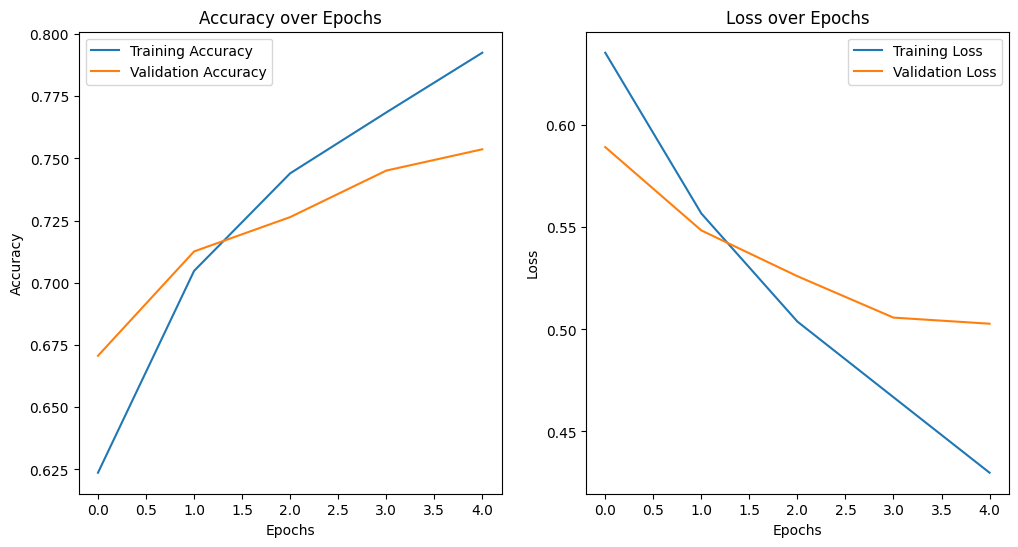

In [22]:
# Fit the model to the training data
# Fit the model using the padded sequences
history = model.fit(X_train_pad,  # Use padded sequences (X_train_pad)
                    y_train,  # Labels (sarcastic or not)
                    epochs=5,  # Number of epochs
                    batch_size=64,  # Batch size
                    validation_data=(X_val_pad, y_val),  # Validation data
                    verbose=1)  # Display progress


# plot training history
import matplotlib.pyplot as plt

# Plot accuracy and loss curves
plt.figure(figsize=(12, 6))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()
